In [104]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

print('OpenCV Version:', cv2.__version__)

OpenCV Version: 5.0.0


### Task 1: Environment Setup, Image I/O & Morphological Operations

In [75]:
# 1.1 Image loading

gray_img = cv2.imread('data/images/image 1.jpg', cv2.IMREAD_GRAYSCALE)

color_img = cv2.imread('data/images/image 2.jpg')

print('Gray Image:')
print('Shape:', gray_img.shape)
print('Data Type:', gray_img.dtype)

print('\nColor Image:')
print('Shape:', color_img.shape)
print('Data Type:', color_img.dtype)


Gray Image:
Shape: (853, 1280)
Data Type: uint8

Color Image:
Shape: (1280, 853, 3)
Data Type: uint8


In [76]:
def show(img, title = 'Image'):
    plt.figure(figsize = (6, 5))

    if len(img.shape) == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
    else:
        plt.imshow(img, cmap = 'gray')

    plt.title(title)
    plt.axis('off')
    plt.show()

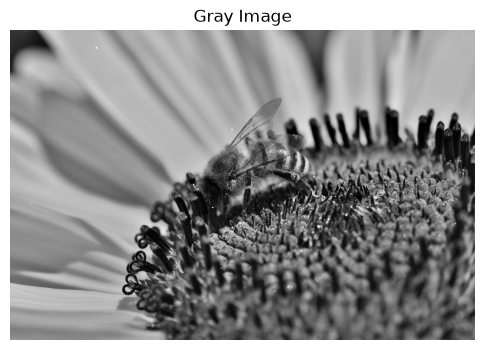

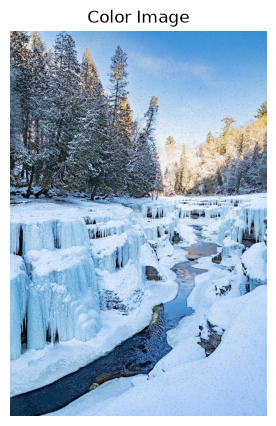

In [77]:
show(gray_img, 'Gray Image')
show(color_img, 'Color Image')

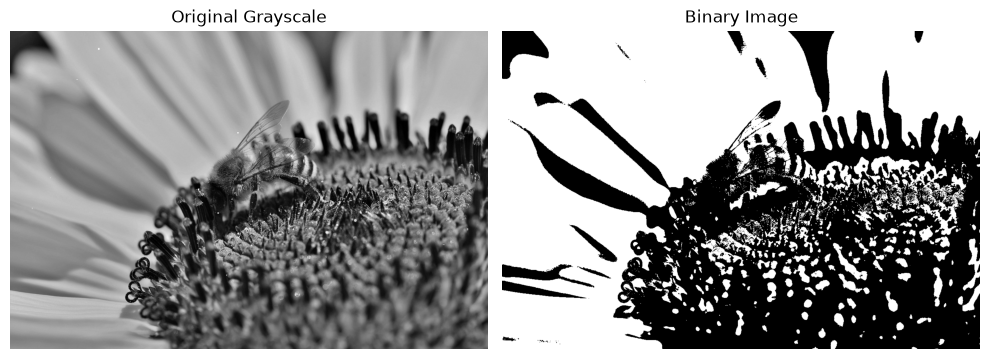

In [78]:
# 1.2 Binarize a test image

gray = gray_img

_, binary = cv2.threshold(
    gray,
    127,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")

plt.tight_layout()
plt.show()

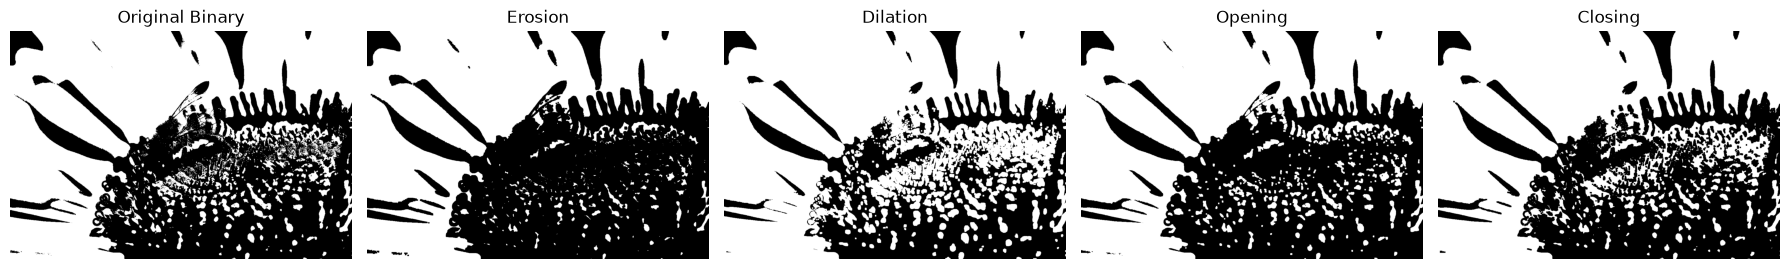

In [79]:
# 1.3 Apply the four morphological operations

kernel = np.ones((5, 5), np.uint8)

eroded = cv2.erode(binary, kernel, iterations=1)

dilated = cv2.dilate(binary, kernel, iterations=1)

opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

images = [
    binary,
    eroded,
    dilated,
    opened,
    closed
]

titles = [
    "Original Binary",
    "Erosion",
    "Dilation",
    "Opening",
    "Closing"
]

plt.figure(figsize=(18, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

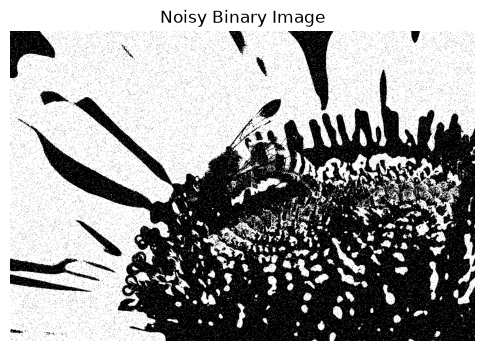

In [80]:
# 1.4 Kernel Shape & Size Comparison

noisy_binary = binary.copy()
rng = np.random.default_rng(42)

salt_mask = rng.random(noisy_binary.shape) < 0.03
noisy_binary[salt_mask] = 255

pepper_mask = rng.random(noisy_binary.shape) < 0.03
noisy_binary[pepper_mask] = 0

show(noisy_binary, "Noisy Binary Image")

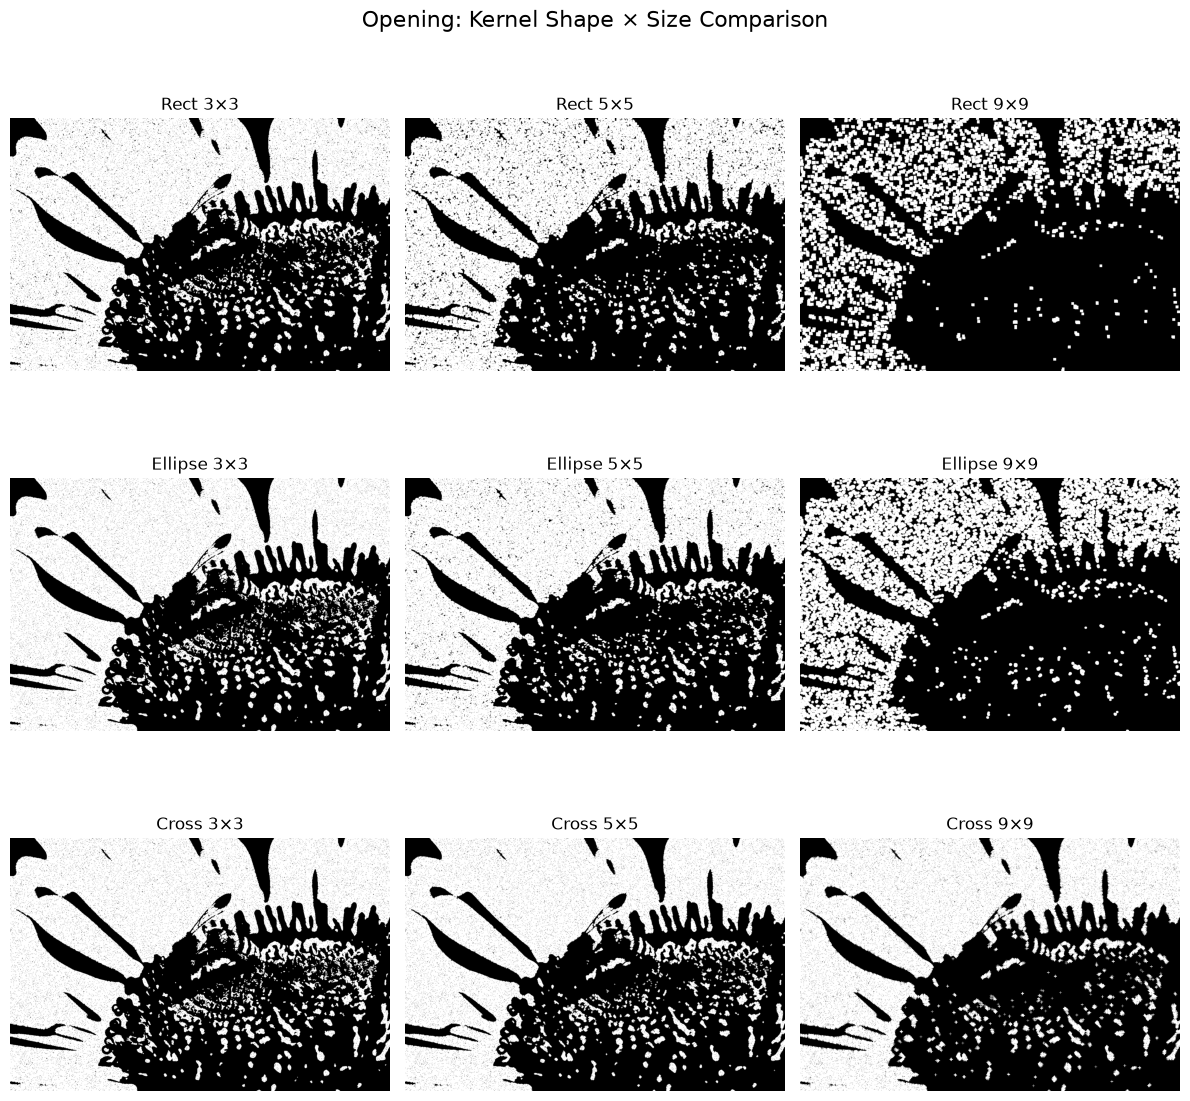

In [81]:
kernel_shapes = {
    "Rect": cv2.MORPH_RECT,
    "Ellipse": cv2.MORPH_ELLIPSE,
    "Cross": cv2.MORPH_CROSS
}

kernel_sizes = [3, 5, 9]

plt.figure(figsize=(12, 12))

plot_index = 1

for shape_name, shape_type in kernel_shapes.items():
    for size in kernel_sizes:

        kernel = cv2.getStructuringElement(
            shape_type,
            (size, size)
        )

        result = cv2.morphologyEx(
            noisy_binary,
            cv2.MORPH_OPEN,
            kernel
        )

        plt.subplot(3, 3, plot_index)
        plt.imshow(result, cmap="gray")
        plt.title(f"{shape_name} {size}×{size}")
        plt.axis("off")

        plot_index += 1

plt.suptitle(
    "Opening: Kernel Shape × Size Comparison",
    fontsize=16
)

plt.tight_layout()
plt.show()

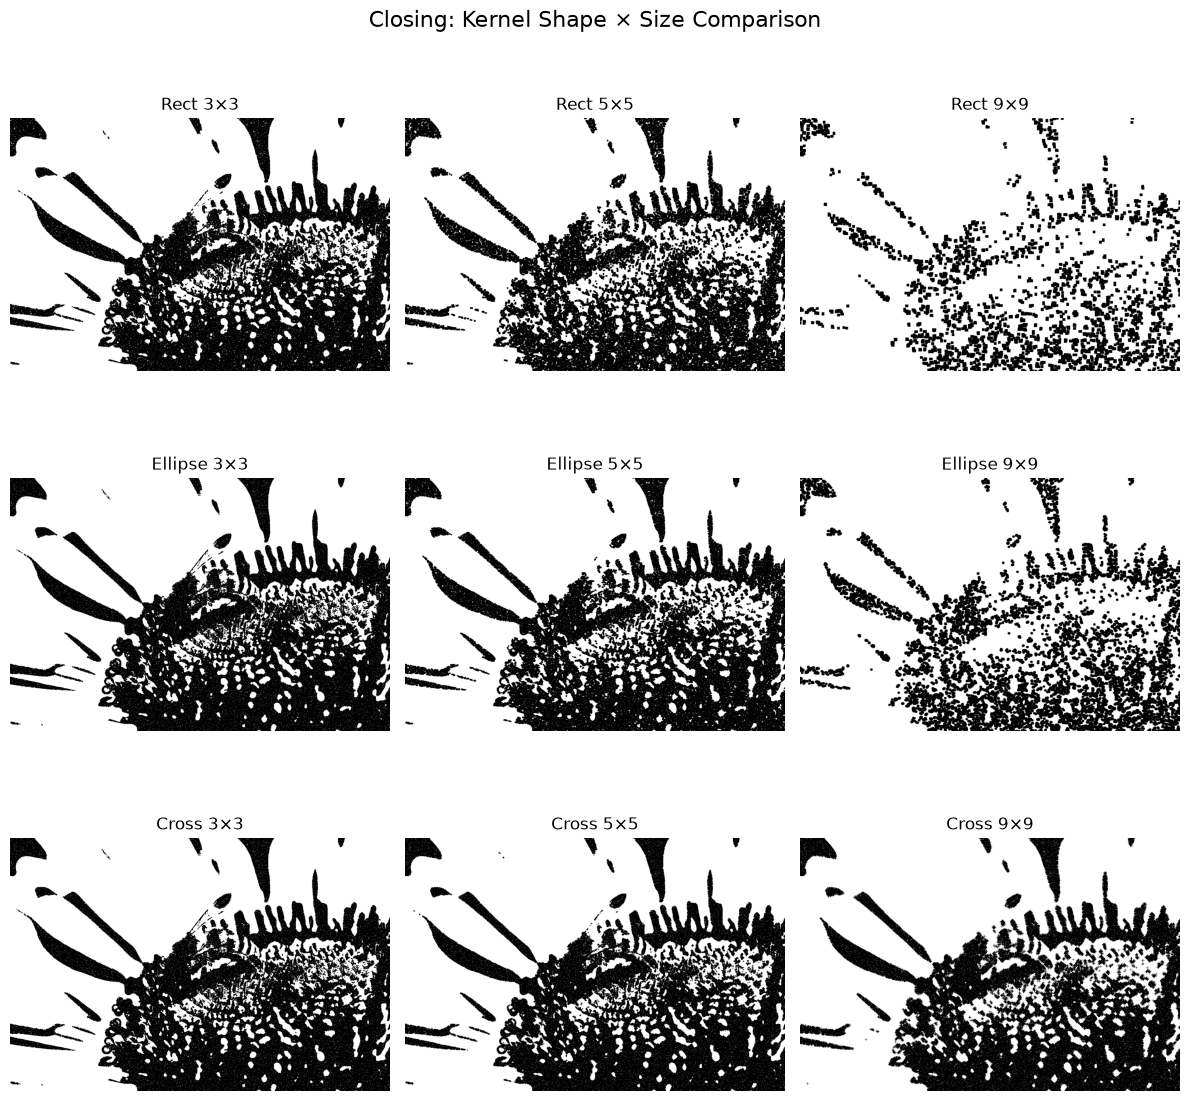

In [82]:
plt.figure(figsize=(12, 12))

plot_index = 1

for shape_name, shape_type in kernel_shapes.items():
    for size in kernel_sizes:

        kernel = cv2.getStructuringElement(
            shape_type,
            (size, size)
        )

        result = cv2.morphologyEx(
            noisy_binary,
            cv2.MORPH_CLOSE,
            kernel
        )

        plt.subplot(3, 3, plot_index)
        plt.imshow(result, cmap="gray")
        plt.title(f"{shape_name} {size}×{size}")
        plt.axis("off")

        plot_index += 1

plt.suptitle(
    "Closing: Kernel Shape × Size Comparison",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Task 2: Bitwise Operations & Image Histograms

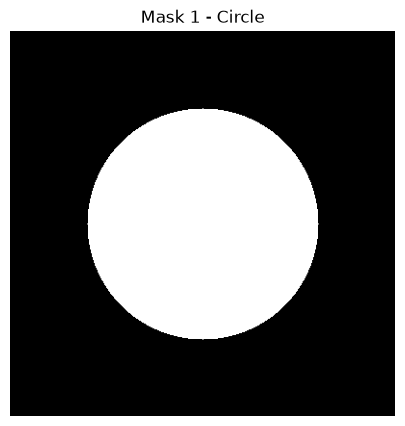

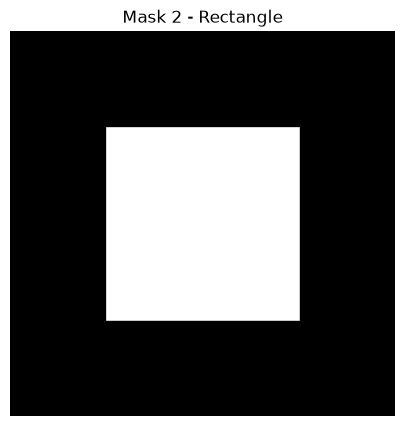

In [83]:
# 2.1 Bitwise AND / OR / XOR / NOT

# Create two blank binary masks
mask1 = np.zeros((400, 400), dtype=np.uint8)
mask2 = np.zeros((400, 400), dtype=np.uint8)

# Circle on mask 1
cv2.circle(
    mask1,
    center=(200, 200),
    radius=120,
    color=255,
    thickness=-1
)

# Rectangle on mask 2
cv2.rectangle(
    mask2,
    pt1=(100, 100),
    pt2=(300, 300),
    color=255,
    thickness=-1
)

show(mask1, "Mask 1 - Circle")
show(mask2, "Mask 2 - Rectangle")

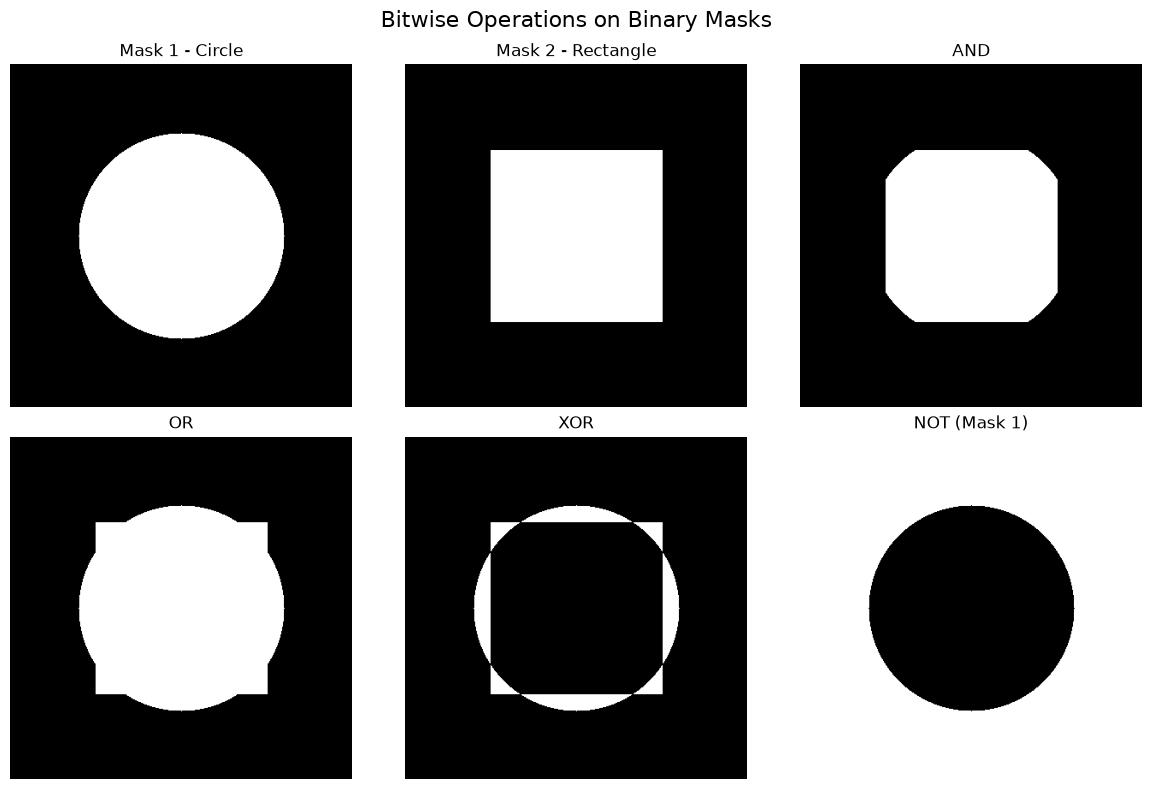

In [84]:
bitwise_and = cv2.bitwise_and(mask1, mask2)

bitwise_or = cv2.bitwise_or(mask1, mask2)

bitwise_xor = cv2.bitwise_xor(mask1, mask2)

bitwise_not = cv2.bitwise_not(mask1)

images = [
    mask1,
    mask2,
    bitwise_and,
    bitwise_or,
    bitwise_xor,
    bitwise_not
]

titles = [
    "Mask 1 - Circle",
    "Mask 2 - Rectangle",
    "AND",
    "OR",
    "XOR",
    "NOT (Mask 1)"
]

plt.figure(figsize=(12, 8))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.suptitle(
    "Bitwise Operations on Binary Masks",
    fontsize=16
)

plt.tight_layout()
plt.show()

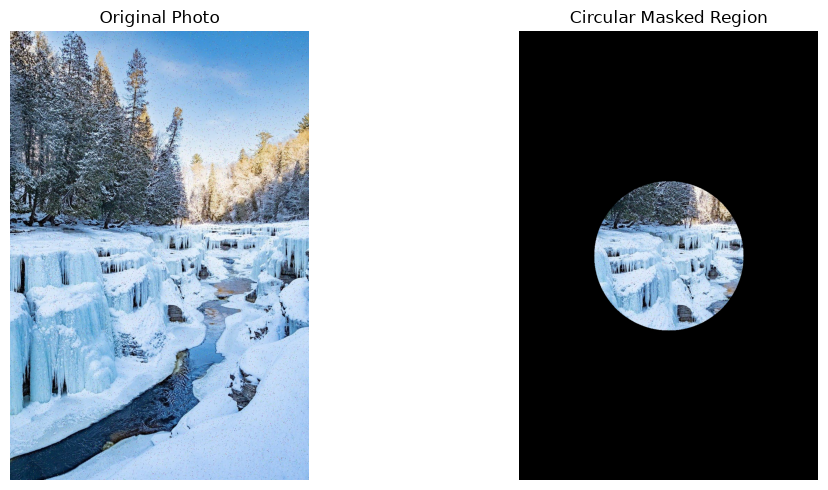

In [85]:
# 2.2 Applied use-case: masked overlay

h, w = color_img.shape[:2]

circle_mask = np.zeros((h, w), dtype=np.uint8)

cv2.circle(
    circle_mask,
    center=(w // 2, h // 2),
    radius=min(h, w) // 4,
    color=255,
    thickness=-1
)

masked_photo = cv2.bitwise_and(
    color_img,
    color_img,
    mask=circle_mask
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB))
plt.title("Original Photo")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(masked_photo, cv2.COLOR_BGR2RGB))
plt.title("Circular Masked Region")
plt.axis("off")

plt.tight_layout()
plt.show()

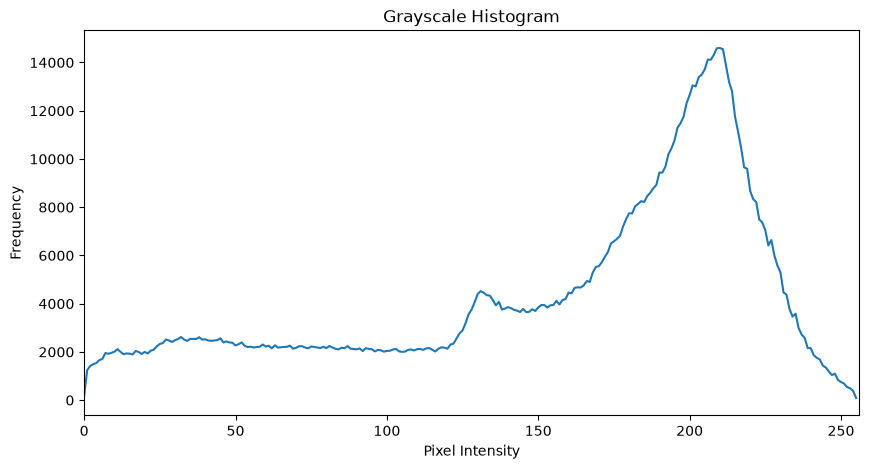

In [86]:
# 2.3 Grayscale & Per-Channel Color Histograms

cv2.calcHist([gray], [0], None, [256], [0, 256])

gray_for_hist = cv2.cvtColor(
    color_img,
    cv2.COLOR_BGR2GRAY
)

gray_hist = cv2.calcHist(
    [gray_for_hist],
    [0],
    None,
    [256],
    [0, 256]
)

plt.figure(figsize=(10, 5))

plt.plot(gray_hist)

plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

plt.show()

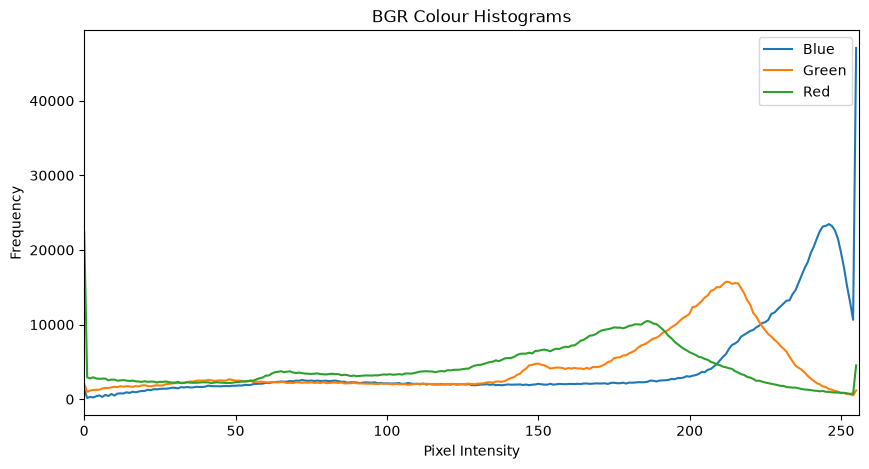

In [87]:
blue_hist = cv2.calcHist(
    [color_img],
    [0],
    None,
    [256],
    [0, 256]
)

green_hist = cv2.calcHist(
    [color_img],
    [1],
    None,
    [256],
    [0, 256]
)

red_hist = cv2.calcHist(
    [color_img],
    [2],
    None,
    [256],
    [0, 256]
)

plt.figure(figsize=(10, 5))

plt.plot(blue_hist, label="Blue")
plt.plot(green_hist, label="Green")
plt.plot(red_hist, label="Red")

plt.title("BGR Colour Histograms")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.legend()

plt.show()

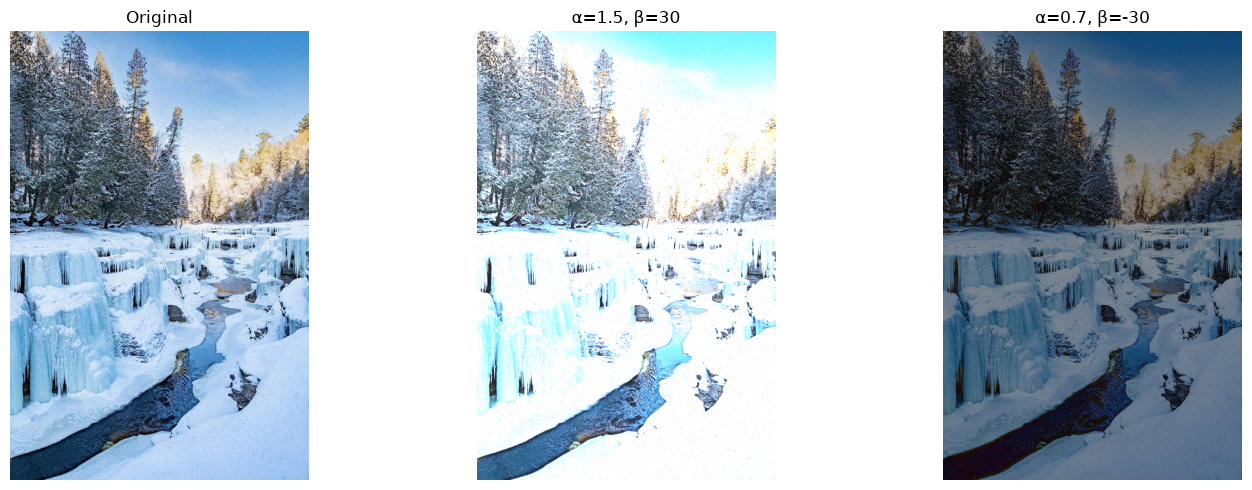

In [88]:
# 2.4 Brightness & contrast

bright_contrast = cv2.convertScaleAbs(
    color_img,
    alpha=1.5,
    beta=30
)

dark_low_contrast = cv2.convertScaleAbs(
    color_img,
    alpha=0.7,
    beta=-30
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(bright_contrast, cv2.COLOR_BGR2RGB))
plt.title("α=1.5, β=30")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(dark_low_contrast, cv2.COLOR_BGR2RGB))
plt.title("α=0.7, β=-30")
plt.axis("off")

plt.tight_layout()
plt.show()

In [89]:
original_gray = cv2.cvtColor(
    color_img,
    cv2.COLOR_BGR2GRAY
)

bright_gray = cv2.cvtColor(
    bright_contrast,
    cv2.COLOR_BGR2GRAY
)

dark_gray = cv2.cvtColor(
    dark_low_contrast,
    cv2.COLOR_BGR2GRAY
)

In [90]:
def calculate_histogram(image):
    return cv2.calcHist(
        [image],
        [0],
        None,
        [256],
        [0, 256]
    )

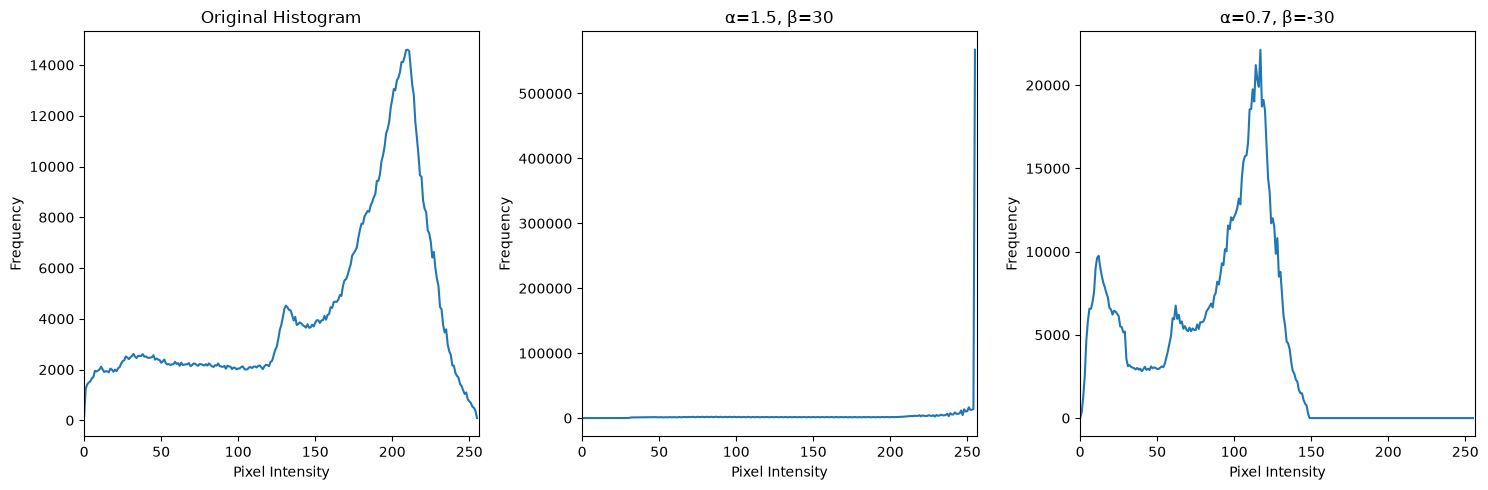

In [91]:
hist_original = calculate_histogram(original_gray)
hist_bright = calculate_histogram(bright_gray)
hist_dark = calculate_histogram(dark_gray)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(hist_original)
plt.title("Original Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

plt.subplot(1, 3, 2)
plt.plot(hist_bright)
plt.title("α=1.5, β=30")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

plt.subplot(1, 3, 3)
plt.plot(hist_dark)
plt.title("α=0.7, β=-30")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

### Task 3: Face Detection with YuNet (OpenCV 5.0)

In [92]:
# 3.1 Load the YuNet Face Detector

yunet_model = "data/models/face_detection_yunet_2023mar.onnx"


img_face = cv2.imread("data/images/face 1.jpg", cv2.IMREAD_COLOR)


img_h, img_w = img_face.shape[:2]

detector = cv2.FaceDetectorYN_create(
    yunet_model,
    "",
    (img_w, img_h),
    score_threshold=0.9
)

detector.setInputSize((img_w, img_h))

print("YuNet detector loaded successfully.")

YuNet detector loaded successfully.


In [93]:
_, faces = detector.detect(img_face)

print("Faces detected:", 0 if faces is None else len(faces))

Faces detected: 1


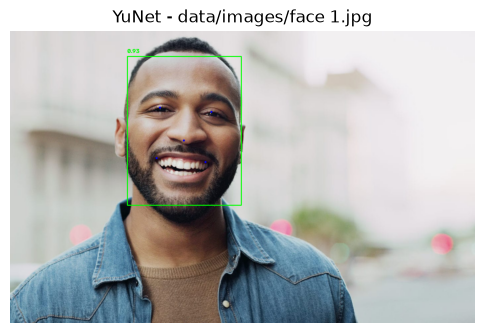

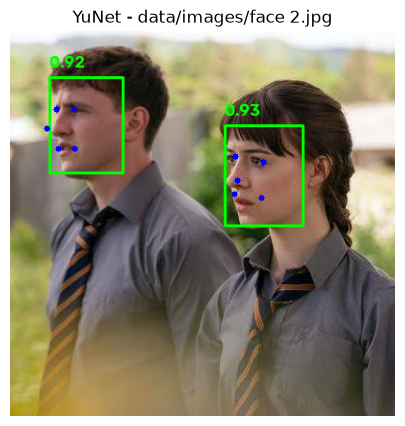

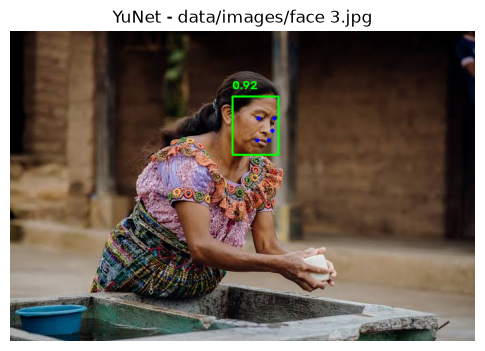

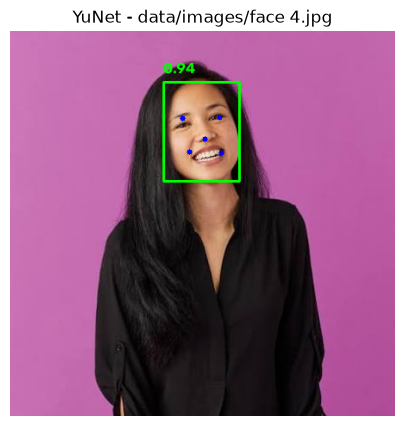

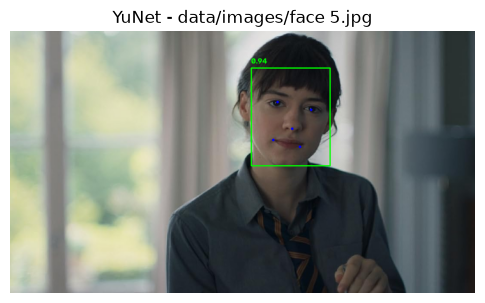

In [96]:
face_image_paths = [
    "data/images/face 2.jpg",
    "data/images/face 3.jpg",
    "data/images/face 4.jpg",
    "data/images/face 5.jpg"
]

for image_path in face_image_paths:

    img = cv2.imread(image_path)

    if img is None:
        print("Could not load:", image_path)
        continue

    h, w = img.shape[:2]

    detector.setInputSize((w, h))

    _, faces = detector.detect(img)

    output = img.copy()

    if faces is not None:
        for face in faces:

            x, y, fw, fh = face[:4].astype(int)

            cv2.rectangle(
                output,
                (x, y),
                (x + fw, y + fh),
                (0, 255, 0),
                2
            )

            landmarks = face[4:14].reshape(5, 2).astype(int)

            for point in landmarks:
                cv2.circle(
                    output,
                    tuple(point),
                    3,
                    (255, 0, 0),
                    -1
                )

            confidence = face[14]

            cv2.putText(
                output,
                f"{confidence:.2f}",
                (x, max(y - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2
            )

    show(output, f"YuNet - {image_path}")

In [97]:
# 3.3 Real-Time Detection on Webcam

import time

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Could not open webcam.")
else:
    print("Webcam opened successfully.")

    frame_count = 0
    start_time = time.time()

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        h, w = frame.shape[:2]

        detector.setInputSize((w, h))

        _, faces = detector.detect(frame)

        if faces is not None:
            for face in faces:

                x, y, fw, fh = face[:4].astype(int)

                cv2.rectangle(
                    frame,
                    (x, y),
                    (x + fw, y + fh),
                    (0, 255, 0),
                    2
                )

                landmarks = face[4:14].reshape(5, 2).astype(int)

                for point in landmarks:
                    cv2.circle(
                        frame,
                        tuple(point),
                        3,
                        (255, 0, 0),
                        -1
                    )

                confidence = face[14]

                cv2.putText(
                    frame,
                    f"{confidence:.2f}",
                    (x, max(y - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 0),
                    2
                )

        frame_count += 1

        elapsed = time.time() - start_time

        if elapsed > 0:
            fps = frame_count / elapsed
        else:
            fps = 0

        cv2.putText(
            frame,
            f"FPS: {fps:.1f}",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            2
        )

        cv2.imshow("YuNet Face Detection", frame)

        # Press q to quit
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()

    print(f"Average FPS: {fps:.2f}")

Webcam opened successfully.
Average FPS: 26.03


In [99]:
# 3.4 Score-threshold experiment & applied privacy use-case

test_face_image = cv2.imread(face_image_paths[0])

h, w = test_face_image.shape[:2]

def detect_with_threshold(image, threshold):

    detector = cv2.FaceDetectorYN_create(
        yunet_model,
        "",
        (image.shape[1], image.shape[0]),
        score_threshold=threshold
    )

    detector.setInputSize(
        (image.shape[1], image.shape[0])
    )

    _, faces = detector.detect(image)

    return faces

In [100]:
thresholds = [0.5, 0.7, 0.9]

threshold_results = {}

for threshold in thresholds:

    faces = detect_with_threshold(
        test_face_image,
        threshold
    )

    count = 0 if faces is None else len(faces)

    threshold_results[threshold] = count

    print(
        f"Threshold {threshold}: "
        f"{count} face(s) detected"
    )

Threshold 0.5: 1 face(s) detected
Threshold 0.7: 1 face(s) detected
Threshold 0.9: 1 face(s) detected


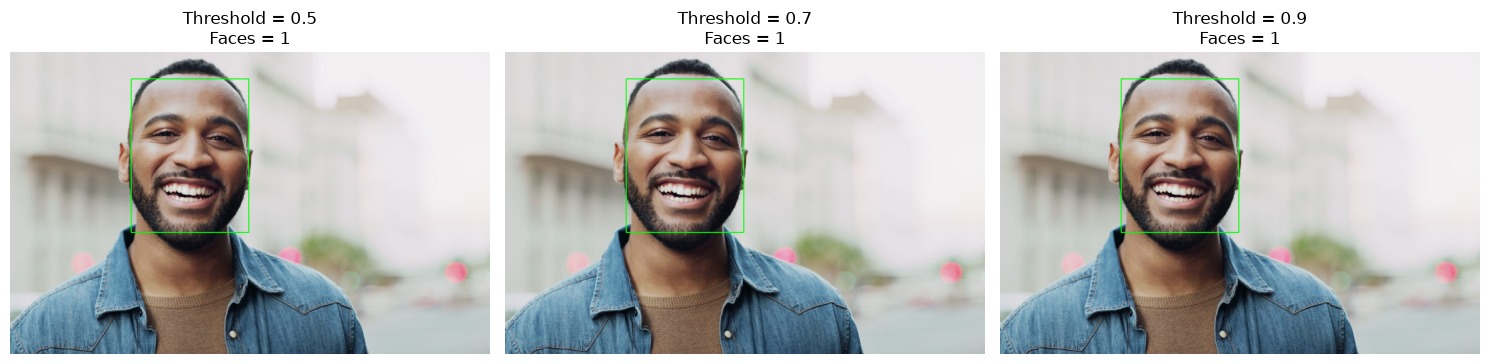

In [101]:
plt.figure(figsize=(15, 5))

for i, threshold in enumerate(thresholds):

    faces = detect_with_threshold(
        test_face_image,
        threshold
    )

    output = test_face_image.copy()

    if faces is not None:
        for face in faces:

            x, y, fw, fh = face[:4].astype(int)

            cv2.rectangle(
                output,
                (x, y),
                (x + fw, y + fh),
                (0, 255, 0),
                2
            )

    plt.subplot(1, 3, i + 1)

    plt.imshow(
        cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
    )

    plt.title(
        f"Threshold = {threshold}\n"
        f"Faces = {0 if faces is None else len(faces)}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

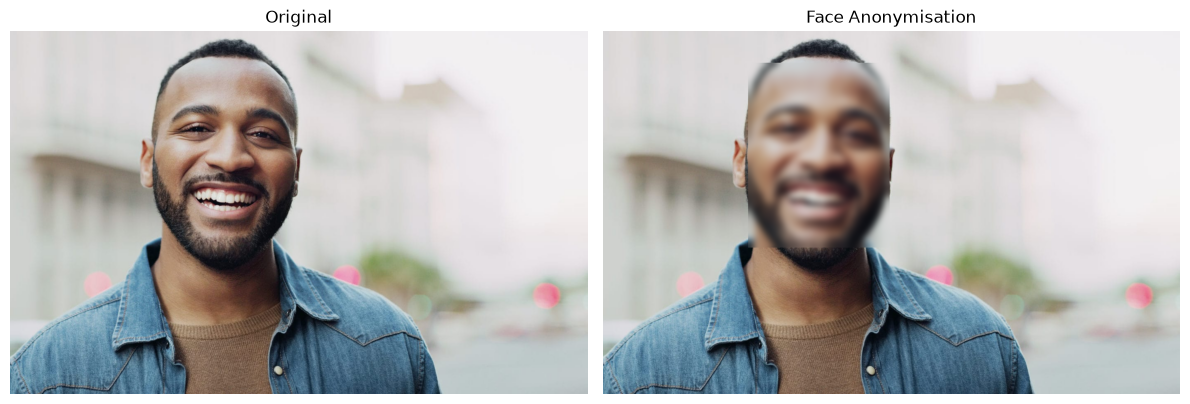

In [103]:
faces = detect_with_threshold(
    test_face_image,
    0.7
)

blurred_image = test_face_image.copy()

if faces is not None:
    for face in faces:

        x, y, w, h = face[:4].astype(int)

        # Keep coordinates inside image boundaries
        x1 = max(0, x)
        y1 = max(0, y)
        x2 = min(blurred_image.shape[1], x + w)
        y2 = min(blurred_image.shape[0], y + h)

        face_region = blurred_image[y1:y2, x1:x2]

        if face_region.size > 0:
            blurred_region = cv2.GaussianBlur(
                face_region,
                (51, 51),
                0
            )

            blurred_image[y1:y2, x1:x2] = blurred_region


faces = detect_with_threshold(
    test_face_image,
    0.7
)

blurred_image = test_face_image.copy()

if faces is not None:
    for face in faces:

        x, y, w, h = face[:4].astype(int)

        # Keep coordinates inside image boundaries
        x1 = max(0, x)
        y1 = max(0, y)
        x2 = min(blurred_image.shape[1], x + w)
        y2 = min(blurred_image.shape[0], y + h)

        face_region = blurred_image[y1:y2, x1:x2]

        if face_region.size > 0:
            blurred_region = cv2.GaussianBlur(
                face_region,
                (51, 51),
                0
            )

            blurred_image[y1:y2, x1:x2] = blurred_region

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(
    cv2.cvtColor(
        test_face_image,
        cv2.COLOR_BGR2RGB
    )
)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    cv2.cvtColor(
        blurred_image,
        cv2.COLOR_BGR2RGB
    )
)
plt.title("Face Anonymisation")
plt.axis("off")

plt.tight_layout()
plt.show()

### Task 4: Object Detection with YOLO

In [107]:
# 4.1 Load pretrained YOLOv8 & run on static images

model = YOLO('data/models/yolov8n.pt')

print("YOLOv8n model loaded successfully.")

YOLOv8n model loaded successfully.



image 1/1 E:\Krish RnW\Deep-Learning-\CV PR3\data\images\face 4.jpg: 640x640 1 person, 117.6ms
Speed: 6.0ms preprocess, 117.6ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


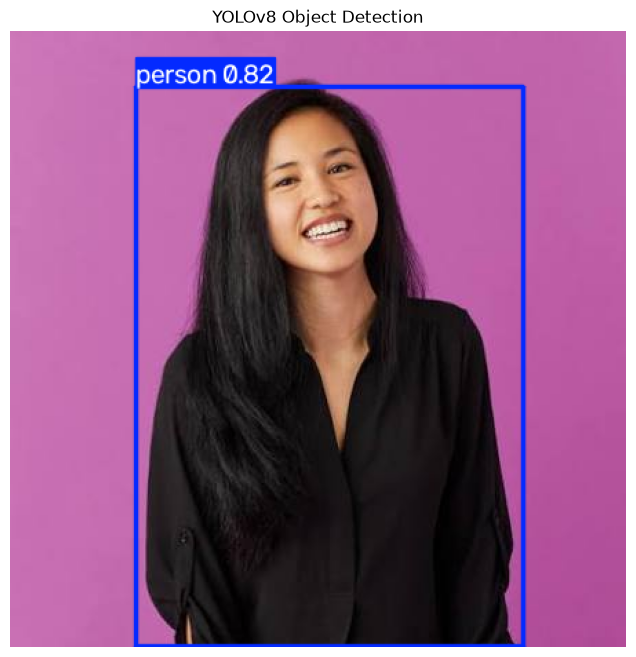

In [110]:
yolo_image_path = "data/images/face 4.jpg"

results = model(yolo_image_path)

annotated_image = results[0].plot()

plt.figure(figsize=(10, 8))

plt.imshow(
    cv2.cvtColor(
        annotated_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("YOLOv8 Object Detection")
plt.axis("off")

plt.show()



image 1/1 E:\Krish RnW\Deep-Learning-\CV PR3\data\images\face 1.jpg: 416x640 1 person, 63.0ms
Speed: 4.8ms preprocess, 63.0ms inference, 1.5ms postprocess per image at shape (1, 3, 416, 640)


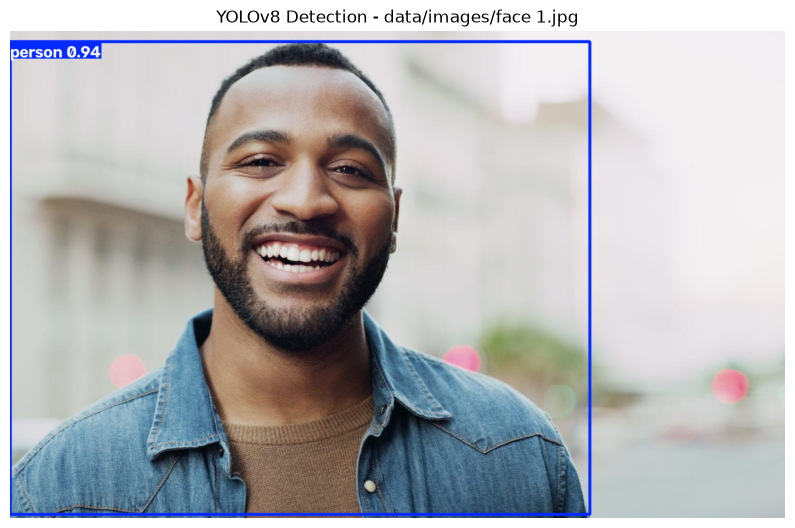


image 1/1 E:\Krish RnW\Deep-Learning-\CV PR3\data\images\face 2.jpg: 640x640 2 persons, 3 ties, 88.2ms
Speed: 5.0ms preprocess, 88.2ms inference, 4.3ms postprocess per image at shape (1, 3, 640, 640)


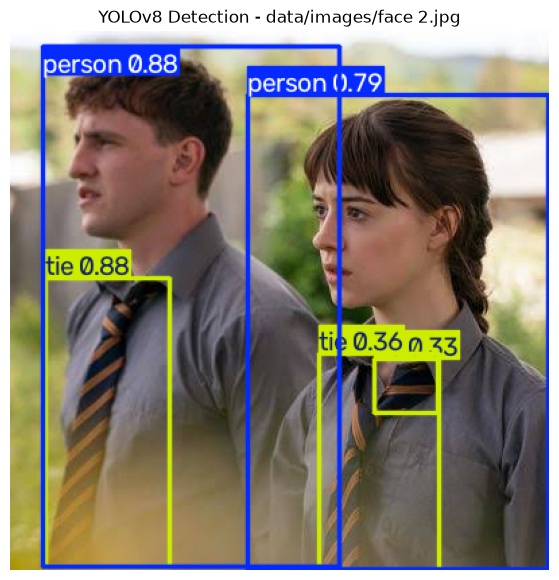


image 1/1 E:\Krish RnW\Deep-Learning-\CV PR3\data\images\face 3.jpg: 448x640 1 person, 1 surfboard, 1 bowl, 75.1ms
Speed: 5.9ms preprocess, 75.1ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)


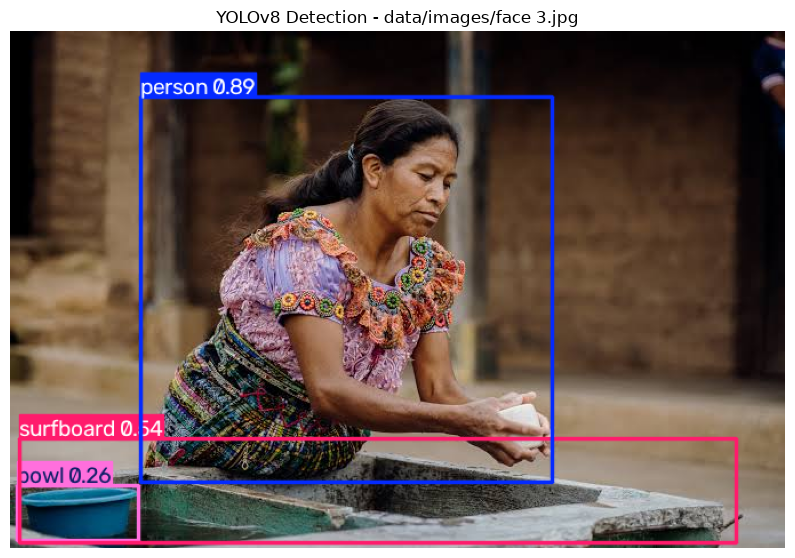

In [111]:
yolo_image_paths = [
    "data/images/face 1.jpg",
    "data/images/face 2.jpg",
    "data/images/face 3.jpg"
]

for image_path in yolo_image_paths:

    results = model(image_path)

    annotated_image = results[0].plot()

    plt.figure(figsize=(10, 7))

    plt.imshow(
        cv2.cvtColor(
            annotated_image,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(f"YOLOv8 Detection - {image_path}")
    plt.axis("off")

    plt.show()

In [112]:
# 4.2 Real-Time YOLO Detection on Webcam

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Could not open webcam.")
else:

    frame_count = 0
    start_time = time.time()

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        # Run YOLO detection
        results = model(
            frame,
            verbose=False
        )

        # Draw bounding boxes and labels
        annotated_frame = results[0].plot()

        # FPS calculation
        frame_count += 1

        elapsed = time.time() - start_time

        if elapsed > 0:
            fps = frame_count / elapsed
        else:
            fps = 0

        cv2.putText(
            annotated_frame,
            f"FPS: {fps:.1f}",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            2
        )

        cv2.imshow(
            "YOLOv8 Object Detection",
            annotated_frame
        )

        # Press q to quit
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()

    print(f"Average FPS: {fps:.2f}")

Average FPS: 14.29


In [113]:
# 4.3 Confidence and IoU Threshold Tuning

test_yolo_image = yolo_image_paths[0]

confidence_values = [0.25, 0.50, 0.75]

confidence_counts = []

for conf in confidence_values:

    results = model(
        test_yolo_image,
        conf=conf,
        verbose=False
    )

    count = len(results[0].boxes)

    confidence_counts.append(count)

    print(
        f"Confidence = {conf}: "
        f"{count} object(s) detected"
    )

Confidence = 0.25: 1 object(s) detected
Confidence = 0.5: 1 object(s) detected
Confidence = 0.75: 1 object(s) detected


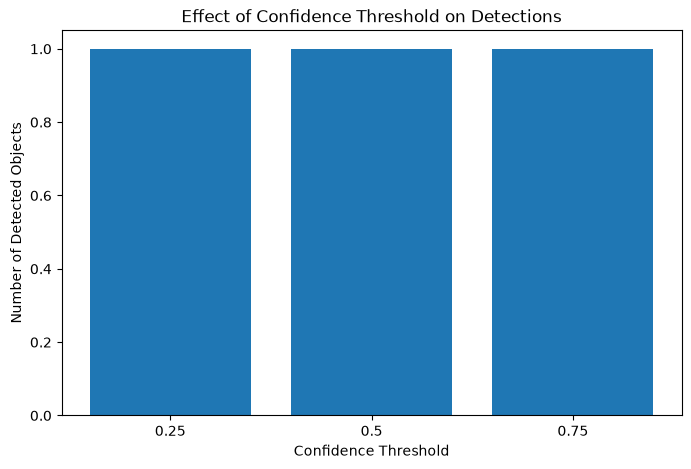

In [114]:
plt.figure(figsize=(8, 5))

plt.bar(
    [str(x) for x in confidence_values],
    confidence_counts
)

plt.title(
    "Effect of Confidence Threshold on Detections"
)

plt.xlabel("Confidence Threshold")
plt.ylabel("Number of Detected Objects")

plt.show()

In [115]:
iou_values = [0.30, 0.50, 0.70]

iou_counts = []

for iou in iou_values:

    results = model(
        test_yolo_image,
        iou=iou,
        verbose=False
    )

    count = len(results[0].boxes)

    iou_counts.append(count)

    print(
        f"IoU = {iou}: "
        f"{count} object(s) detected"
    )

IoU = 0.3: 1 object(s) detected
IoU = 0.5: 1 object(s) detected
IoU = 0.7: 1 object(s) detected


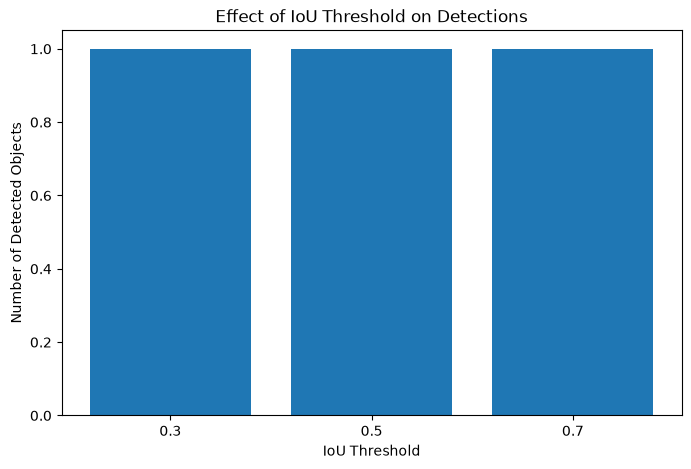

In [116]:
plt.figure(figsize=(8, 5))

plt.bar(
    [str(x) for x in iou_values],
    iou_counts
)

plt.title(
    "Effect of IoU Threshold on Detections"
)

plt.xlabel("IoU Threshold")
plt.ylabel("Number of Detected Objects")

plt.show()

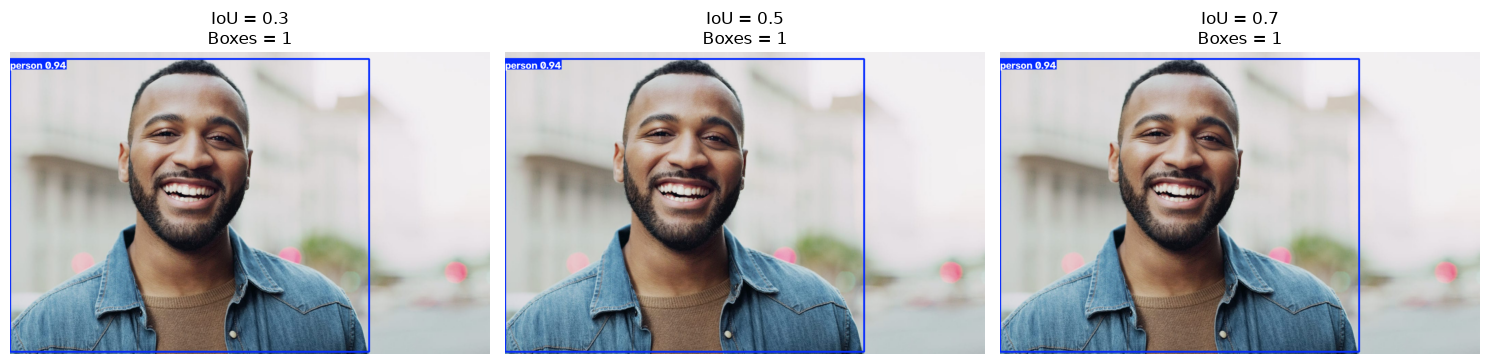

In [117]:
plt.figure(figsize=(15, 5))

for i, iou in enumerate(iou_values):

    results = model(
        test_yolo_image,
        iou=iou,
        verbose=False
    )

    annotated = results[0].plot()

    plt.subplot(1, 3, i + 1)

    plt.imshow(
        cv2.cvtColor(
            annotated,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(
        f"IoU = {iou}\n"
        f"Boxes = {len(results[0].boxes)}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

### Task 5: Integrated Pipeline & Final Comparison

In [125]:
# 5.1 Build the unified pipeline

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Could not open webcam.")
else:

    while True:

        ret, frame = cap.read()

        if not ret:
            break



        results = model(
            frame,
            verbose=False
        )

        # Draw YOLO boxes in RED
        if results[0].boxes is not None:

            for box in results[0].boxes:

                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)

                confidence = float(box.conf[0])

                class_id = int(box.cls[0])

                class_name = model.names[class_id]

                cv2.rectangle(
                    frame,
                    (x1, y1),
                    (x2, y2),
                    (0, 0, 255),
                    2
                )

                cv2.putText(
                    frame,
                    f"{class_name} {confidence:.2f}",
                    (x1, max(y1 - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 0, 255),
                    2
                )


        h, w = frame.shape[:2]

        detector.setInputSize((w, h))

        _, faces = detector.detect(frame)

        if faces is not None:

            for face in faces:

                x, y, fw, fh = face[:4].astype(int)

                confidence = face[14]

                # GREEN YuNet box
                cv2.rectangle(
                    frame,
                    (x, y),
                    (x + fw, y + fh),
                    (0, 255, 0),
                    2
                )

                # 5 landmarks
                landmarks = face[4:14].reshape(5, 2).astype(int)

                for point in landmarks:

                    cv2.circle(
                        frame,
                        tuple(point),
                        3,
                        (0, 255, 0),
                        -1
                    )

                cv2.putText(
                    frame,
                    f"Face {confidence:.2f}",
                    (x, max(y - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 0),
                    2
                )



        cv2.imshow(
            "YuNet + YOLO Integrated Pipeline",
            frame
        )

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()

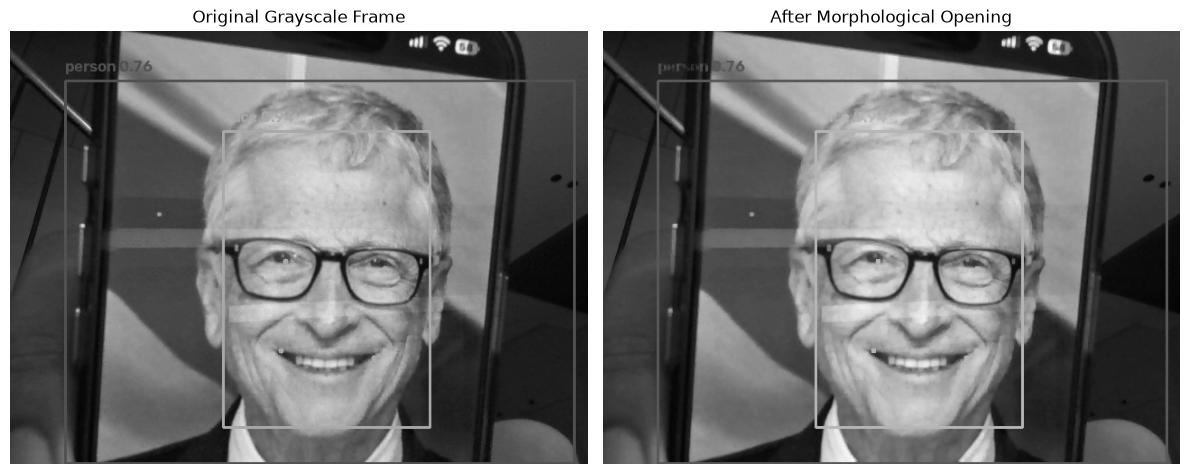

In [126]:
# 5.2 Covert webcam frame to grayscale

gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

kernel = np.ones((3, 3), np.uint8)

morph_clean = cv2.morphologyEx(
    gray_frame,
    cv2.MORPH_OPEN,
    kernel
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_frame, cmap="gray")
plt.title("Original Grayscale Frame")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(morph_clean, cmap="gray")
plt.title("After Morphological Opening")
plt.axis("off")

plt.tight_layout()
plt.show()

In [127]:
# 5.3 Capture 100 webcam frames

cap = cv2.VideoCapture(0)

frames = []

for i in range(100):

    ret, frame = cap.read()

    if not ret:
        break

    frames.append(frame.copy())

cap.release()

print("Frames captured:", len(frames))

Frames captured: 100


In [128]:
start_time = time.time()

for frame in frames:

    h, w = frame.shape[:2]

    detector.setInputSize((w, h))

    detector.detect(frame)

yunet_time = time.time() - start_time

yunet_fps = len(frames) / yunet_time

print(f"YuNet FPS: {yunet_fps:.2f}")

YuNet FPS: 27.06


In [129]:
start_time = time.time()

for frame in frames:

    model(
        frame,
        verbose=False
    )

yolo_time = time.time() - start_time

yolo_fps = len(frames) / yolo_time

print(f"YOLO FPS: {yolo_fps:.2f}")

YOLO FPS: 17.78


In [130]:
start_time = time.time()

for frame in frames:

    # YuNet
    h, w = frame.shape[:2]

    detector.setInputSize((w, h))

    detector.detect(frame)

    # YOLO
    model(
        frame,
        verbose=False
    )

combined_time = time.time() - start_time

combined_fps = len(frames) / combined_time

print(f"Combined FPS: {combined_fps:.2f}")

Combined FPS: 9.83


In [131]:
print("========== FPS BENCHMARK ==========")
print(f"YuNet Only    : {yunet_fps:.2f} FPS")
print(f"YOLO Only     : {yolo_fps:.2f} FPS")
print(f"YuNet + YOLO  : {combined_fps:.2f} FPS")

========== FPS BENCHMARK ==========
YuNet Only    : 27.06 FPS
YOLO Only     : 17.78 FPS
YuNet + YOLO  : 9.83 FPS


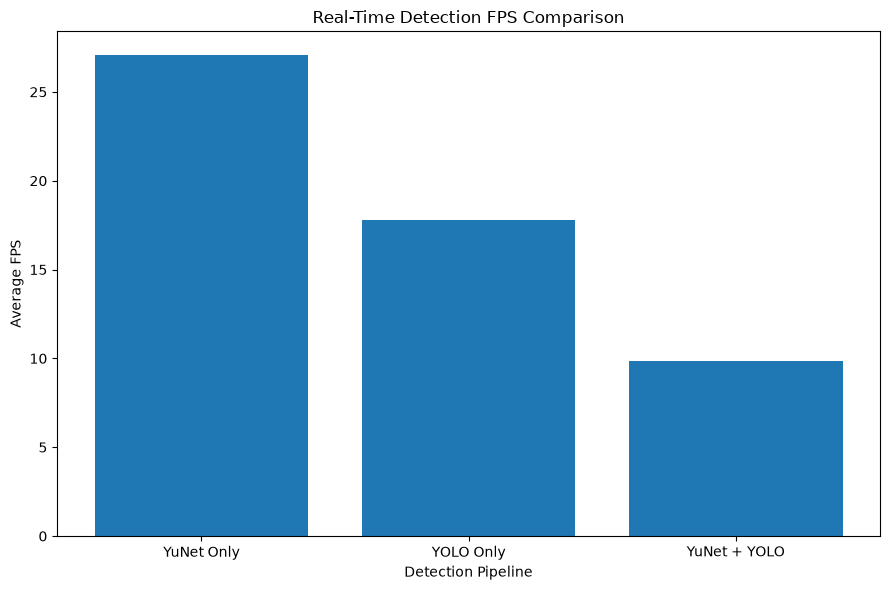

In [132]:
techniques = [
    "YuNet Only",
    "YOLO Only",
    "YuNet + YOLO"
]

fps_values = [
    yunet_fps,
    yolo_fps,
    combined_fps
]

plt.figure(figsize=(9, 6))

plt.bar(
    techniques,
    fps_values
)

plt.title(
    "Real-Time Detection FPS Comparison"
)

plt.xlabel("Detection Pipeline")
plt.ylabel("Average FPS")

plt.tight_layout()

plt.show()

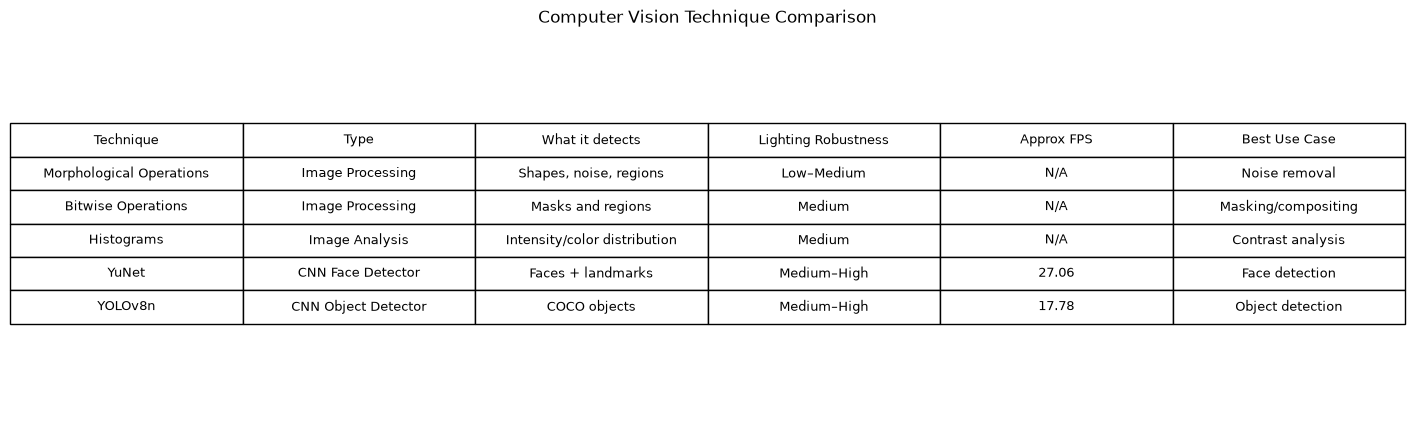

In [134]:
# 5.4 Create comparison table

table_data = [
    [
        "Morphological Operations",
        "Image Processing",
        "Shapes, noise, regions",
        "Low–Medium",
        "N/A",
        "Noise removal"
    ],
    [
        "Bitwise Operations",
        "Image Processing",
        "Masks and regions",
        "Medium",
        "N/A",
        "Masking/compositing"
    ],
    [
        "Histograms",
        "Image Analysis",
        "Intensity/color distribution",
        "Medium",
        "N/A",
        "Contrast analysis"
    ],
    [
        "YuNet",
        "CNN Face Detector",
        "Faces + landmarks",
        "Medium–High",
        f"{yunet_fps:.2f}",
        "Face detection"
    ],
    [
        "YOLOv8n",
        "CNN Object Detector",
        "COCO objects",
        "Medium–High",
        f"{yolo_fps:.2f}",
        "Object detection"
    ]
]

columns = [
    "Technique",
    "Type",
    "What it detects",
    "Lighting Robustness",
    "Approx FPS",
    "Best Use Case"
]

fig, ax = plt.subplots(
    figsize=(18, 5)
)

ax.axis("off")

table = ax.table(
    cellText=table_data,
    colLabels=columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

plt.title(
    "Computer Vision Technique Comparison"
)

plt.show()